# Clean up tiny pieces

‘consensus’’ network assignment was derived by collapsing assignments across thresholds, giving each node the assignment it had at the sparsest possible threshold at which it was successfully assigned to one of the known group networks
contiguous network pieces that were `smaller than 30 mm2 were removed`, following (Gordon et al., 2017a),


--> Translation of Matlab Code from
https://github.com/MidnightScanClub/MSCcodebase/blob/master/Utilities/Infomap_wrapper/consensus_maker_knowncolors.m
--> 

In [3]:
from nilearn import image
from nilearn import surface
import os.path as op
import numpy as np
import nibabel as nib

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'

ses=1
task='magjudge'
conn_thresholds = [0.03, 0.04, 0.05, 0.1, 0.2, 0.4] 
conn_thresholds_string = "-".join([str(t) for t in conn_thresholds])
confspec = '36Pscrub3BPfilter'

source_folder = op.join(bids_folder,'derivatives','networks_infomap_full') #, f'sub-{sub}')


In [ ]:
sub = '01'
fn_consens_mapping = op.join(source_folder, f'sub-{sub}_ses-{ses}_task-{task}_consensusMapping_threshs-{conn_thresholds_string}_confspec-{confspec}.npy')
consensus_labels = np.load(fn_consens_mapping)

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


Text(0.5, 0.75, 'sub 01')

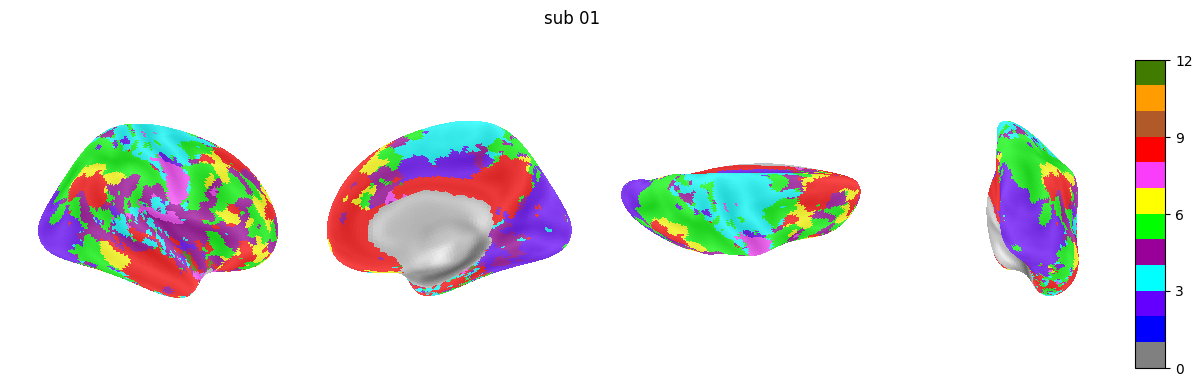

In [11]:
from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()

modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = consensus_labels


from utils import plot_nets_CAcolors
figure = plot_nets_CAcolors(modules_fsav5, hemi_to_plot='R')
figure.suptitle(f'sub {sub}', y=0.75)

## Translation of Matlab Code from
https://github.com/MidnightScanClub/MSCcodebase/blob/master/Utilities/Infomap_wrapper/consensus_maker_knowncolors.m

% Clean up tiny pieces

Repeat for all networks:
1. Find all vertices with that label
2. Build connected components restricted to that label using surface neighbors
3. For each connected component:
    If its size < minsize (in vertices)
    Reassign it to the most common neighboring network label


In [4]:
from nilearn import surface
import numpy as np

def build_vertex_neighbors(faces, n_vertices):
    neighbors = [[] for _ in range(n_vertices)]
    for tri in faces:
        a, b, c = tri # all vertices of the triangle - each vertex gets the other two as neighbors
        neighbors[a].extend([b, c])
        neighbors[b].extend([a, c])
        neighbors[c].extend([a, b])
    return [np.unique(n) for n in neighbors] # remove duplicates

# list of n_vertices with arrays of their neighbors (differen amount for each vertex)

In [5]:
from nilearn import datasets, surface
fsavg = datasets.fetch_surf_fsaverage("fsaverage5")
coords_L, faces_L = surface.load_surf_mesh(fsavg.pial_left)
coords_R, faces_R = surface.load_surf_mesh(fsavg.pial_right)

neighbors_L = build_vertex_neighbors(faces_L, coords_L.shape[0]) # list with n_vertices and their neighbors (differen amount for each vertex)
neighbors_R = build_vertex_neighbors(faces_R, coords_R.shape[0])


In [6]:
import numpy as np
from scipy.stats import mode

def cleanup_small_patches(consensus_labels, neighbors, minsize):
    """
    Python translation of Gordon et al. cluster cleanup code.
    
    Parameters
    ----------
    consensus_labels : (N,) ndarray
        Final network assignment per vertex
    neighbors : list of arrays
        neighbors[v] gives neighboring vertex indices
    minsize : int
        Minimum cluster size (in vertices)
    """
    temp_out = consensus_labels.copy()
    allcolors = np.unique(temp_out)
    allcolors = allcolors[allcolors > 0]  # exclude unassigned / background

    for color in allcolors: # colors = labels / networks
        clusteredmetric = np.zeros_like(temp_out, dtype=int)
        thiscolorverts = np.where(temp_out == color)[0]

        # --- build connected components ---
        for vertex in thiscolorverts:
            vertexneighbors = neighbors[vertex]
            vertexneighbors_thiscolor = np.intersect1d(thiscolorverts, vertexneighbors, assume_unique=True)

            uniqueneighborvals = np.unique(clusteredmetric[vertexneighbors_thiscolor])
            uniqueneighborvals = uniqueneighborvals[uniqueneighborvals != 0]

            if len(uniqueneighborvals) == 0:
                clusteredmetric[vertexneighbors_thiscolor] = vertex

            elif len(uniqueneighborvals) == 1:
                clusteredmetric[vertexneighbors_thiscolor] = uniqueneighborvals[0]

            else:
                # merge clusters
                mainval = uniqueneighborvals[0]
                for val in uniqueneighborvals[1:]:
                    clusteredmetric[clusteredmetric == val] = mainval

        # --- remove small clusters ---
        uniqueclustervals = np.unique(clusteredmetric)
        uniqueclustervals = uniqueclustervals[uniqueclustervals != 0]

        for clusterval in uniqueclustervals:
            clusterverts = np.where(clusteredmetric == clusterval)[0]

            if len(clusterverts) < minsize:
                neighborverts = np.unique(np.concatenate([neighbors[v] for v in clusterverts]))

                borderverts = np.setdiff1d(neighborverts, clusterverts)
                borderverts = borderverts[temp_out[borderverts] > 0]

                if len(borderverts) > 0:
                    mode_neighborval = mode(temp_out[borderverts], keepdims=False).mode
                    temp_out[clusterverts] = mode_neighborval

    return temp_out


In [ ]:
n_hemi = 10242  # fsaverage5
labels_L = modules_fsav5[:n_hemi] #consensus_labels[:n_hemi]
labels_R = modules_fsav5[n_hemi:]

clean_L = cleanup_small_patches(labels_L, neighbors_L, minsize=30)
clean_R = cleanup_small_patches(labels_R, neighbors_R, minsize=30)

consensus_cleaned = np.concatenate([clean_L, clean_R])



Text(0.5, 0.75, 'sub 01')

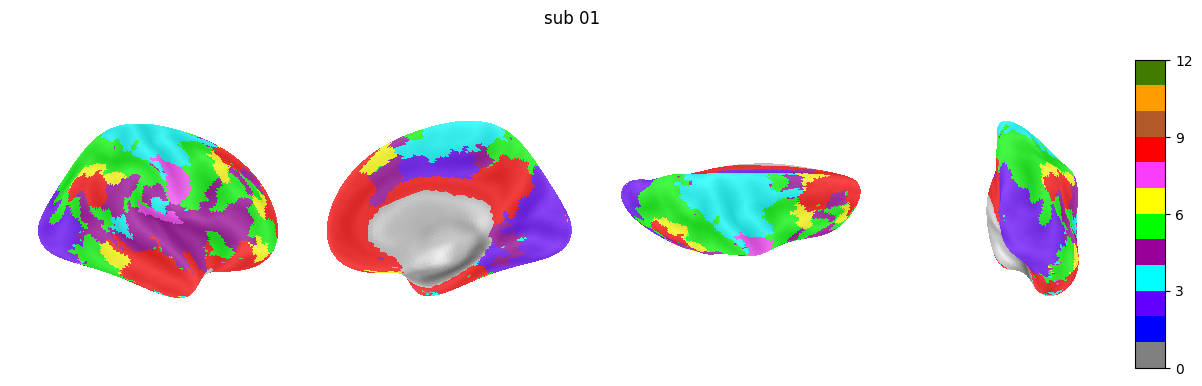

In [13]:
from utils import plot_nets_CAcolors
figure = plot_nets_CAcolors(consensus_cleaned, hemi_to_plot='R')
figure.suptitle(f'sub {sub}', y=0.75)

## Apply to all subjects

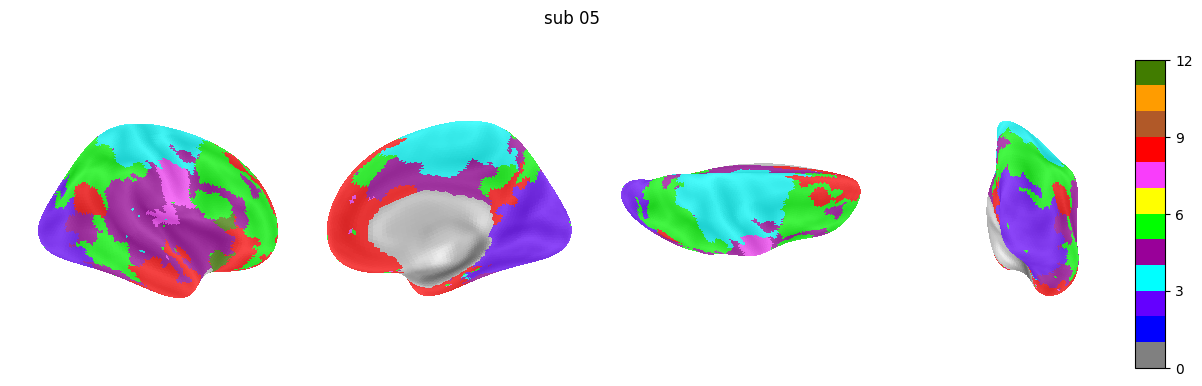

In [12]:
sub = '05'
consensus_labels = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
modules_fsav5[mask] = consensus_labels

labels_L = modules_fsav5[:n_hemi] #consensus_labels[:n_hemi]
labels_R = modules_fsav5[n_hemi:]
clean_L = cleanup_small_patches(labels_L, neighbors_L, minsize=30)
clean_R = cleanup_small_patches(labels_R, neighbors_R, minsize=30)
consensus_cleaned = np.concatenate([clean_L, clean_R])
np.save(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter_cleaned_fsaverage5.npy'), consensus_cleaned)

figure = plot_nets_CAcolors(consensus_cleaned, hemi_to_plot='R')
figure.suptitle(f'sub {sub}', y=0.75)
plot_fn = op.join(plot_folder, f'sub-{sub}_ses-{ses}_task-{task}_networks_infomap_hemi-R_confspec-{confspec}_cleaned.png')

figure.savefig(plot_fn, dpi=300, bbox_inches='tight')


In [ ]:
net_folder = op.join(bids_folder, 'derivatives', 'networks_infomap_full_01')
plot_folder = op.join(bids_folder,'plots_and_ims','networks_infomap_full_cleaned')
 
subList = [f'{sub:02d}' for sub in range(1, 67)]

import matplotlib.pyplot as plt
from utils import plot_nets_CAcolors

from numrisk.fmri_analysis.gradients.utils import get_basic_mask
mask, labeling_noParcel = get_basic_mask()
n_hemi = 10242  # fsaverage5


for sub in subList[7:]:
        try:    
                consensus_labels = np.load(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter.npy'))
                modules_fsav5 = np.full(mask.shape[0], np.nan, dtype=float)
                modules_fsav5[mask] = consensus_labels

                labels_L = modules_fsav5[:n_hemi] #consensus_labels[:n_hemi]
                labels_R = modules_fsav5[n_hemi:]
                clean_L = cleanup_small_patches(labels_L, neighbors_L, minsize=30)
                clean_R = cleanup_small_patches(labels_R, neighbors_R, minsize=30)
                consensus_cleaned = np.concatenate([clean_L, clean_R])
                np.save(op.join(net_folder, f'sub-{sub}_consensusMapping_confspec-36Pscrub3BPfilter_cleaned_fsaverage5.npy'), consensus_cleaned)
                
                figure = plot_nets_CAcolors(consensus_cleaned, hemi_to_plot='R')
                figure.suptitle(f'sub {sub}', y=0.75)
                plot_fn = op.join(plot_folder, f'sub-{sub}_ses-{ses}_task-{task}_networks_infomap_hemi-R_confspec-{confspec}_cleaned.png')
                figure.savefig(plot_fn, dpi=300, bbox_inches='tight')
                plt.close(figure)
                print(f'sub-{sub} finished!')
        except Exception as e:
                print(f'sub-{sub} failed: {e}')

        

sub-08 finished!
sub-09 finished!
sub-10 finished!
sub-11 finished!
sub-12 finished!
sub-13 finished!
sub-14 finished!
sub-15 finished!
sub-16 finished!
sub-17 finished!
sub-18 finished!
sub-19 finished!
sub-20 finished!
sub-21 finished!
sub-22 finished!
sub-23 finished!
sub-24 finished!
sub-25 finished!
sub-26 finished!
sub-27 finished!
sub-28 finished!
sub-29 finished!
sub-30 finished!
sub-31 finished!
sub-32 finished!
sub-33 finished!
sub-34 finished!
sub-35 finished!
sub-36 finished!
sub-37 finished!
sub-38 finished!
sub-39 finished!
sub-40 finished!
sub-41 finished!
sub-42 finished!
sub-43 finished!
sub-44 finished!
sub-45 finished!
sub-46 finished!
sub-47 finished!
sub-48 finished!
sub-49 finished!
sub-50 finished!
sub-51 finished!
sub-52 finished!
sub-53 finished!
sub-54 finished!
sub-55 finished!
sub-56 finished!
sub-57 finished!
sub-58 finished!
sub-59 finished!
sub-60 finished!
sub-61 finished!
sub-62 finished!
sub-63 finished!
sub-64 finished!
sub-65 finished!
sub-66 finishe

## Original attempt from ChatGPT

In [ ]:
source_folder = op.join(bids_folder, 'derivatives', 'correlation_matrices.tryNoHalo') # .parcel
geo_dist_L = np.load(op.join(source_folder, f'geo_dist_fsav5_hemi-lh.npy'))
geo_dist_R = np.load(op.join(source_folder, f'geo_dist_fsav5_hemi-rh.npy'))
geo_dist_L.shape

In [43]:
import numpy as np
from nilearn import surface

def compute_vertex_areas(coords, faces):
    """
    Approximate per-vertex surface area from triangle faces.
    """
    def triangle_area(v0, v1, v2):
        return 0.5 * np.linalg.norm(np.cross(v1 - v0, v2 - v0), axis=1)

    tris = coords[faces]  # (n_faces, 3, 3) - -- each face's 3 vertices with 3D coords
    areas = triangle_area(tris[:, 0], tris[:, 1], tris[:, 2])  # (n_faces,) - -- area of each triangle face

    vertex_areas = np.zeros(coords.shape[0])
    for i in range(3):
        np.add.at(vertex_areas, faces[:, i], areas / 3.0) # Distribute area equally (1/3) to all 3 vertices of each triangle 

    return vertex_areas


In [44]:
# Load or prepare mesh
from nilearn import datasets
fsavg = datasets.fetch_surf_fsaverage('fsaverage5')

hemi = 'L'
coords, faces = surface.load_surf_mesh(fsavg.pial_left) 
# face = triangles that divide the mesh - stored as an integer matrix where each row lists the three vertex indices forming that triangle. 

# Compute per-vertex areas
vertex_areas = compute_vertex_areas(coords, faces)


In [45]:
from scipy import ndimage

def remove_small_clusters(consensus_map, coords, faces, vertex_areas, area_thresh=30.0):
    """
    Removes spatially contiguous network patches < area_thresh mm².
    """
    cleaned = consensus_map.copy()
    n_vertices = len(consensus_map)

    # Build adjacency list from faces
    adjacency = [[] for _ in range(n_vertices)]
    for tri in faces:
        for i in range(3):
            adjacency[tri[i]].extend([tri[(i+1)%3], tri[(i+2)%3]])
    adjacency = [list(set(neigh)) for neigh in adjacency]

    # For each unique label (excluding -1)
    for label in np.unique(cleaned):
        if label == -1:
            continue

        mask = (cleaned == label)
        if not np.any(mask):
            continue

        # Connected component labeling
        labeled_array, n_components = ndimage.label(mask, structure=build_connectivity(adjacency))

        for comp_id in range(1, n_components + 1):
            component_mask = (labeled_array == comp_id)
            comp_area = vertex_areas[component_mask].sum()

            if comp_area < area_thresh:
                cleaned[component_mask] = -1

    return cleaned

def build_connectivity(adjacency):
    """
    Build connectivity matrix for ndimage.label from mesh adjacency.
    This creates a (n, n) sparse boolean matrix indicating connections.
    """
    from scipy.sparse import lil_matrix

    n = len(adjacency)
    conn = lil_matrix((n, n), dtype=bool)
    for i, neighbors in enumerate(adjacency):
        conn[i, neighbors] = True

    # ndimage.label requires a square structuring element for 1D arrays.
    # We'll cheat by doing it in 1D.
    return conn.toarray()


In [47]:
coords.shape

(10242, 3)

In [51]:
consensus_map_hemi = consensus_labels[:10242]  ############### Choose hemisphere here ###############

cleaned = consensus_map_hemi.copy()
n_vertices = len(consensus_map_hemi)

# Build adjacency list from faces
adjacency = [[] for _ in range(n_vertices)]
for tri in faces:
    for i in range(3):
        adjacency[tri[i]].extend([tri[(i+1)%3], tri[(i+2)%3]])
adjacency = [list(set(neigh)) for neigh in adjacency]



In [60]:
np.shape(adjacency)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10242,) + inhomogeneous part.

In [54]:
label = np.unique(cleaned)[3]
print(label)
mask = (cleaned == label)
mask

5


array([False,  True, False, ..., False, False, False])

In [55]:
build_connectivity(adjacency)

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False,  True, False],
       [False, False, False, ...,  True, False,  True],
       [False, False, False, ..., False,  True, False]])

In [ ]:
# For each unique label (excluding -1)
for label in np.unique(cleaned):
    if label == -1:
        continue

    mask = (cleaned == label)
    if not np.any(mask):
        continue

    # Connected component labeling
    labeled_array, n_components = ndimage.label(mask, structure=build_connectivity(adjacency))

    for comp_id in range(1, n_components + 1):
        component_mask = (labeled_array == comp_id)
        comp_area = vertex_areas[component_mask].sum()

        if comp_area < area_thresh:
            cleaned[component_mask] = -1

In [49]:
consensus_map.shape

(10242,)

In [50]:
consensus_map_hemi = consensus_labels[:10242]  ############### Choose hemisphere here ###############

# Apply cleanup
consensus_cleaned = remove_small_clusters(
    consensus_map_hemi, coords, faces, vertex_areas, area_thresh=30.0
)


RuntimeError: structure and input must have equal rank